In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

In [9]:
# Loading the Amazon UK Product Insights (assuming the file name is "amz_uk_price_prediction_dataset")
amz_uk_df = pd.read_csv("amz_uk_price_prediction_dataset.csv")

amz_uk_df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [10]:
amz_uk_df.shape

(2443651, 9)

In [11]:
amz_uk_df.dtypes

uid                    int64
asin                  object
title                 object
stars                float64
reviews                int64
price                float64
isBestSeller            bool
boughtInLastMonth      int64
category              object
dtype: object

In [16]:
# PART 1 -- Understanding Product Categories
# Business Question: What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?

# 1.1 -- Frequency Tables:
# Generate a frequency table for the product category.
# Which are the top 5 most listed product categories?

frequency_table = amz_uk_df['category'].value_counts()
frequency_table

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Alexa Built-In Devices                       107
Motorbike Chassis                            107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

In [17]:
top_five = frequency_table.nlargest(5)
top_five

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

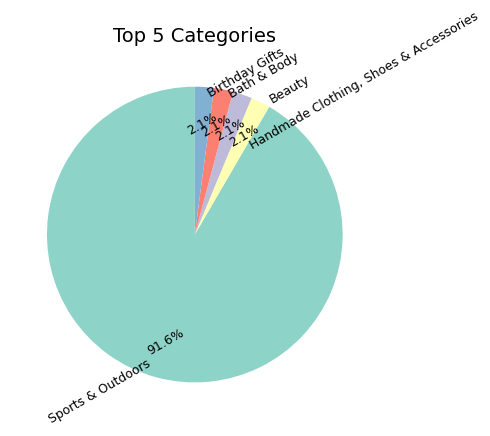

In [29]:
# 1.2 -- Visualizations:
# Display the distribution of products across different categories using a bar chart. 
# If you face problems understanding the chart, do it for a subset of top categories.
# For a subset of top categories, visualize their proportions using a pie chart. Does any category dominate the listings?

top_five.plot.pie(autopct='%1.1f%%', pctdistance=0.75, startangle=90, textprops={'fontsize': 9}, colors=sns.color_palette("Set3"))
plt.ylabel("")  # remove o label "count"
plt.title("Top 5 Categories", fontsize=14)

# Rotate all text elements (labels and percentage values)
for text in plt.gca().texts:
    text.set_rotation(30)   # change the angle (ex.: 30 graus)

plt.show()

In [30]:
# PART 2 -- Delving into Product Pricing
# Business Question: How are products priced on Amazon UK, and are there specific price points or ranges that are more common?

# 2.1 -- Measures of Centrality:
# Calculate the mean, median, and mode for the price of products.
# What's the average price point of products listed? How does this compare with the most common price point (mode)?

mean_price = amz_uk_df['price'].mean()
median_price = amz_uk_df['price'].median()
mode_price = amz_uk_df['price'].mode()[0]

mean_price, median_price, mode_price

(np.float64(89.24380943923661), 19.09, np.float64(9.99))

In [ ]:
# Average price point (mean): £89.24
# Median price: £19.09
# Most common price point (mode): £9.99

# There is a big gap between the average price and the most common price (mode). 
# The average (£89.24) is significantly higher than both the median (£19.09) and the most common price point (£9.99)

In [32]:
# 2.2 -- Measures of Dispersion:
# Determine the variance, standard deviation, range, and interquartile range for product price.
# How varied are the product prices? Are there any indicators of a significant spread in prices?

variance_price = amz_uk_df['price'].var()
std_dev_price = amz_uk_df['price'].std()
min_price = amz_uk_df['price'].min()
max_price = amz_uk_df['price'].max()
range_price = max_price - min_price
quantiles_price = amz_uk_df['price'].quantile([0.25, 0.5, 0.75])

variance_price.print
std_dev_price. print
min_price.print
max_price. print
range_price.print
quantiles_price.print

AttributeError: 'float' object has no attribute 'print'

In [ ]:
# 3.3 -- Visualizations:
# Is there a specific price range where most products fall? Plot a histogram to visualize the distribution of product prices. 
# If its hard to read these diagrams, think why this is, and explain how it could be solved..
# Are there products that are priced significantly higher than the rest? Use a box plot to showcase the spread and potential outliers
# in product pricing.